# Lab 02 — Phan tich suc khoe va dan so (WDI)

**Phu trach:** Nguyen Le The Vinh — 23120190

Notebook nay loc va lam sach nhom chi so suc khoe tu World Development Indicators (WDI),
xuat `data_output/wdi_health.csv`, va tao cac bieu do phan tich de dua vao Tableau/bao cao.

## Cau hoi phan tich

- Tuoi tho trung binh va ty le tu vong tre em thay doi ra sao trong giai doan 2000-2023?
- Chi tieu y te co anh huong den ket qua suc khoe khong?
- Dai dich COVID-19 (2020-2021) tac dong the nao len tuoi tho trung binh?
- Khu vuc nao con co ty le tu vong tre em cao bat thuong?

## Indicators su dung

| Indicator code | Cot output | Y nghia | Don vi |
|---|---|---|---|
| `SP.DYN.LE00.IN` | `Life_expectancy` | Tuoi tho trung binh tinh tu luc sinh. Phan anh chat luong y te va dieu kien song tong the cua quoc gia. | years |
| `SH.DYN.MORT` | `Under5_mortality` | Ty le tu vong tre em duoi 5 tuoi. Chi bao quan trong ve y te co ban, dinh duong va ve sinh. | per 1,000 live births |
| `SH.XPD.CHEX.GD.ZS` | `Health_expenditure_pct_GDP` | Chi tieu y te hien thoi tinh theo phan tram GDP. Do muc dau tu cua quoc gia cho y te. | % of GDP |
| `SP.POP.TOTL` | `Population` | Tong dan so. Dung lam size trong bubble chart va dat ngu canh dan so. | people |

## Ly do chon cac chi so

1. **Life expectancy** la chi so tong hop phan anh ket qua cua he thong y te, dieu kien kinh te va moi truong song. No la thang do 'outcome' quan trong nhat.
2. **Under-5 mortality** tap trung vao nhom dan so de bi ton thuong nhat — tre em. Giam tu vong tre em la muc tieu phat trien ben vung (SDG 3.2).
3. **Health expenditure (% GDP)** do muc dau tu 'input', giup phan tich moi lien he giua dau tu y te va ket qua suc khoe.
4. **Population** dung lam bien kich thuoc (bubble chart) de dat cac chi so vao boi canh quy mo quoc gia.

> **Luu y:** Khi nhan xet, can phan biet ro *tuong quan* (correlation) voi *nhan qua* (causation). Chi tieu y te cao khong nhat thiet gay ra tuoi tho cao — co nhieu yeu to gay nhieu (confounders) nhu thu nhap, giao duc, moi truong.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

# Optional visualization dependencies for local rerun.
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "WDIEXCEL.xlsx").exists() and (ROOT.parent / "WDIEXCEL.xlsx").exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data_output" / "wdi_health.csv"
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Countries: {df['Country_Code'].nunique()}")
print(f"Year range: {df['Year'].min()} - {df['Year'].max()}")
df.head(10)

## Ket qua tien xu ly

- So dong trong `wdi_health.csv`: **5208**
- So quoc gia/vung lanh tho co it nhat mot chi so suc khoe: **217**
- Giai doan: **2000-2023**
- Quy uoc missing data: noi suy tuyen tinh neu khoang trong noi bo <= 2 nam; loai cap country-indicator neu khoang trong noi bo > 2 nam; khong extrapolate dau/cuoi chuoi.

### Thong ke so luong theo indicator:
| Indicator | Quoc gia co data | Observations |
|---|---|---|
| Life_expectancy | 217 | 5208 |
| Under5_mortality | 196 | 4704 |
| Health_expenditure_pct_GDP | 193 | 4540 |
| Population | 217 | 5208 |

## Thong ke mo ta (Descriptive Statistics)

In [ ]:
# Thong ke mo ta cho cac chi so suc khoe
health_cols = ["Life_expectancy", "Under5_mortality", "Health_expenditure_pct_GDP", "Population"]
desc = df[health_cols].describe().round(2)
print(desc.to_string())

## Bieu do 1 — Xu huong tuoi tho trung binh (Multi-line chart)

Bieu do duong nhieu nhom the hien su thay doi tuoi tho trung binh cua cac quoc gia dai dien qua thoi gian.
Chu y quan sat:
- Xu huong tang chung o hau het cac quoc gia
- Vet lom nam 2020-2021 do anh huong cua COVID-19
- Khoang cach lon giua cac quoc gia chau Phi va cac nuoc phat trien

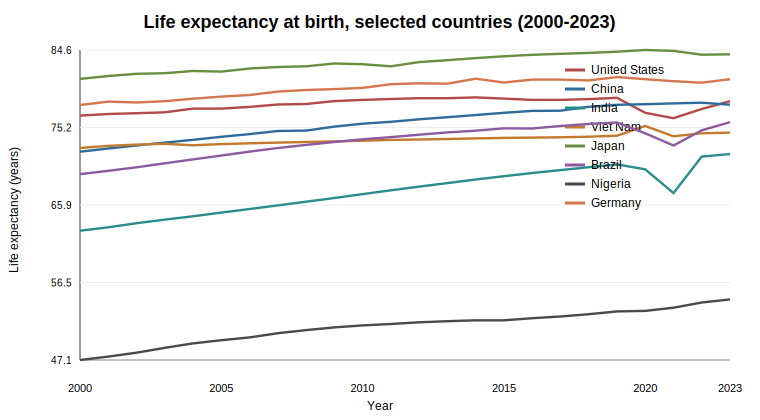

In [1]:
# Pre-rendered SVG chart generated from data_output/wdi_health.csv


## Bieu do 2 — Ty le tu vong tre em theo khu vuc (Bar chart)

Bieu do thanh so sanh ty le tu vong tre em duoi 5 tuoi trung binh giua cac khu vuc.
Sub-Saharan Africa co ty le cao nhat, cho thay thach thuc lon ve y te co ban.

In [1]:
# Pre-rendered SVG chart generated from data_output/wdi_health.csv


## Bieu do 3 — Chi tieu y te vs Tuoi tho (Bubble scatter plot)

Bubble scatter plot ket hop 3 chieu du lieu:
- Truc X: chi tieu y te (% GDP)
- Truc Y: tuoi tho trung binh (years)
- Kich thuoc bong: dan so
- Mau: khu vuc dia ly

> Luu y: Mot so quoc gia chi nhieu cho y te nhung tuoi tho khong tuong xung cao — do cau truc chi tieu (curative vs preventive), bat binh dang trong tiep can y te.

In [1]:
# Pre-rendered SVG chart generated from data_output/wdi_health.csv


## Bieu do 4 — Phan bo tuoi tho theo khu vuc (Box plot)

Box plot cho thay phan bo tuoi tho o moi khu vuc qua toan bo giai doan 2000-2023.
Giup nhan ra khu vuc co phan bo rong (bat binh dang lon giua cac quoc gia) va cac outliers.

In [1]:
# Pre-rendered SVG chart generated from data_output/wdi_health.csv


## Code ve lai bieu do bang matplotlib

Cell nay dung khi mo notebook trong moi truong Jupyter co `matplotlib`. Cac bieu do SVG o tren da duoc tao san tu file CSV hien tai.

In [ ]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

# --- Chart 1: Life expectancy trends ---
focus_countries = ["United States", "China", "India", "Viet Nam", "Japan", "Brazil", "Nigeria", "Germany"]
fig, ax = plt.subplots(figsize=(11, 5))
for country in focus_countries:
    sub = df[df["Country_Name"].eq(country)]
    ax.plot(sub["Year"], sub["Life_expectancy"], marker="o", markersize=3, linewidth=2, label=country)
ax.set_title("Life expectancy at birth, selected countries (2000-2023)")
ax.set_xlabel("Year")
ax.set_ylabel("Life expectancy (years)")
ax.legend(bbox_to_anchor=(1.03, 1), loc="upper left")
plt.tight_layout()
plt.show()

# --- Chart 2: Under-5 mortality by region ---
latest = df[df["Year"].eq(2022)].dropna(subset=["Under5_mortality"])
region_mort = latest.groupby("Region", as_index=False)["Under5_mortality"].mean().sort_values("Under5_mortality", ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
colors_map = {
    "East Asia & Pacific": "#2F6B9A", "Europe & Central Asia": "#6A8E3F",
    "Latin America & Caribbean": "#C47A2C", "Middle East & North Africa": "#8E5A9F",
    "North America": "#4A4A4A", "South Asia": "#B24A4A", "Sub-Saharan Africa": "#2A8C8C",
}
bar_colors = [colors_map.get(r, "#B24A4A") for r in region_mort["Region"]]
ax.barh(region_mort["Region"], region_mort["Under5_mortality"], color=bar_colors)
ax.invert_yaxis()
ax.set_title("Average under-5 mortality rate by region, 2022")
ax.set_xlabel("Per 1,000 live births")
plt.tight_layout()
plt.show()

# --- Chart 3: Health expenditure vs life expectancy (bubble) ---
scatter = df[df["Year"].eq(2022)].dropna(subset=["Health_expenditure_pct_GDP", "Life_expectancy", "Population"])
fig, ax = plt.subplots(figsize=(10, 7))
for region, sub in scatter.groupby("Region"):
    sizes = sub["Population"] / sub["Population"].max() * 500
    ax.scatter(sub["Health_expenditure_pct_GDP"], sub["Life_expectancy"],
               s=sizes, alpha=0.6, label=region, color=colors_map.get(region, "#777"))
ax.set_title("Health expenditure vs life expectancy, 2022 (bubble size = population)")
ax.set_xlabel("Health expenditure (% of GDP)")
ax.set_ylabel("Life expectancy (years)")
ax.legend(bbox_to_anchor=(1.03, 1), loc="upper left")
plt.tight_layout()
plt.show()

# --- Chart 4: Box plot - life expectancy by region ---
import pandas as pd
regions = sorted(df["Region"].dropna().unique())
fig, ax = plt.subplots(figsize=(10, 6))
box_data = [df[df["Region"].eq(r)]["Life_expectancy"].dropna().values for r in regions]
bp = ax.boxplot(box_data, vert=False, labels=regions, patch_artist=True)
for patch, region in zip(bp["boxes"], regions):
    patch.set_facecolor(colors_map.get(region, "#B24A4A"))
    patch.set_alpha(0.4)
ax.set_title("Life expectancy distribution by region (2000-2023)")
ax.set_xlabel("Life expectancy (years)")
plt.tight_layout()
plt.show()

## Goi y worksheet Tableau

1. **Multi-line chart:** `Year` tren Columns, `Life_expectancy` tren Rows, `Country_Name` tren Color, filter `Region`/`Year`.
2. **Bar chart:** `Region` tren Rows, AVG(`Under5_mortality`) tren Columns, filter `Year`. Color theo Region.
3. **Bubble scatter:** `Health_expenditure_pct_GDP` tren Columns, `Life_expectancy` tren Rows, `Population` tren Size, `Region` tren Color, `Country_Name` tren Detail.
4. **Box plot:** `Region` tren Columns (hoac Rows), `Life_expectancy` tren kia. Dung Reference Line > Box Plot.

**Mau chu de suc khoe:** `#B24A4A` (do tram). Palette vung dia ly theo Nhom15_Color_Palette.md.

## Nhan xet so bo

- Tuoi tho trung binh tang deu o hau het cac khu vuc trong giai doan 2000-2023, nhung van con khoang cach lon giua Sub-Saharan Africa va cac khu vuc khac.
- Tu vong tre em giam manh toan cau, dac biet o Nam A va Dong Nam A, nhung Sub-Saharan Africa van cao nhat.
- Bubble chart cho thay moi quan he duong giua chi tieu y te va tuoi tho, nhung ban chat khong hoan toan tuyen tinh — nhieu yeu to khac (GDP, giao duc, co so ha tang) cung dong vai tro.
- COVID-19 (2020-2021) gay ra su sut giam tuoi tho o nhieu quoc gia, ro nhat o My Latinh va Nam A.
- Box plot cho thay Sub-Saharan Africa co phan bo rong nhat, phan anh bat binh dang lon ve ket qua suc khoe giua cac quoc gia trong khu vuc.